# Day 12: Introduction to Tracking Data (Metrica Sports)

**Phase 1: Foundations & Infrastructure**

## Objective
Explore Metrica Sports open tracking data to understand player movement, coordinate systems, and basic kinematics (distance and speed).

## Task
- [x] Download and load Metrica Sports tracking data (Home/Away teams) from Game 1 using `src/data/loaders.py`.
- [x] Fix multi-header CSV parsing to correctly identify 'Frame', 'Time', and Player positions.
- [x] Implement spatial visualization for individual frames using Matplotlib (Top-down view).
- [x] Engineer a kinematic function to calculate cumulative distance (km) and peak velocity (km/h).
- [x] Document physical performance metrics for key players.

---


In [4]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path for imports
sys.path.append(os.path.abspath("../../"))
from src.data.loaders import load_metrica_tracking

# Metrica Sample Game 1 URLs
HOME_URL = 'https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_1/Sample_Game_1_RawTrackingData_Home_Team.csv'
AWAY_URL = 'https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_1/Sample_Game_1_RawTrackingData_Away_Team.csv'

# Load data using our robust loader
home_tracking = load_metrica_tracking(HOME_URL, "Home")
away_tracking = load_metrica_tracking(AWAY_URL, "Away")

print(f"\nHome Columns Sample: {list(home_tracking.columns[:10])}")
home_tracking.head()

2026-05-12 21:33:57 - INFO - Downloading Metrica tracking data for Home...
2026-05-12 21:33:58 - INFO - Successfully loaded tracking data for Home. Shape: (145006, 33)
2026-05-12 21:33:58 - INFO - Downloading Metrica tracking data for Away...
2026-05-12 21:33:58 - INFO - Successfully loaded tracking data for Away. Shape: (145006, 33)



Home Columns Sample: ['Period', 'Frame', 'Time [s]', 'Home_11_X', 'Home_11_Y', 'Home_1_X', 'Home_1_Y', 'Home_2_X', 'Home_2_Y', 'Home_3_X']


,Period,Frame,Time [s],Home_11_X,Home_11_Y,Home_1_X,Home_1_Y,Home_2_X,Home_2_Y,Home_3_X,...,Home_10_X,Home_10_Y,Home_12_X,Home_12_Y,Home_13_X,Home_13_Y,Home_14_X,Home_14_Y,Ball_X,Ball_Y
0,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
1,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
2,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
3,1,4,0.16,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,...,0.55236,0.43313,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
4,1,5,0.20,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,...,0.55202,0.43311,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570


### 1. Understanding the Tracking Data Structure

Unlike event data (which only records actions like passes), tracking data captures the position of **all players and the ball** at a high frequency.

- **Frame Rate**: Metrica data is captured at **25 Hz** (25 frames per second). This means the time between frames is exactly **0.04 seconds**.
- **Coordinates**: Values are normalized between **0 and 1**. 
  - (0,0) is usually the top-left corner.
  - (0.5, 0.5) is the center of the pitch.
- **Columns**: Our loader renamed them to `Team_PlayerID_X` and `Team_PlayerID_Y` for easy access.

### 2. Spatial Visualization (Top-Down View)

We will visualize a specific frame to see the tactical setup of both teams. We've upgraded this to a professional **Dark Theme** pitch with approximated pitch lines mapped to the 0-1 normalized coordinates.

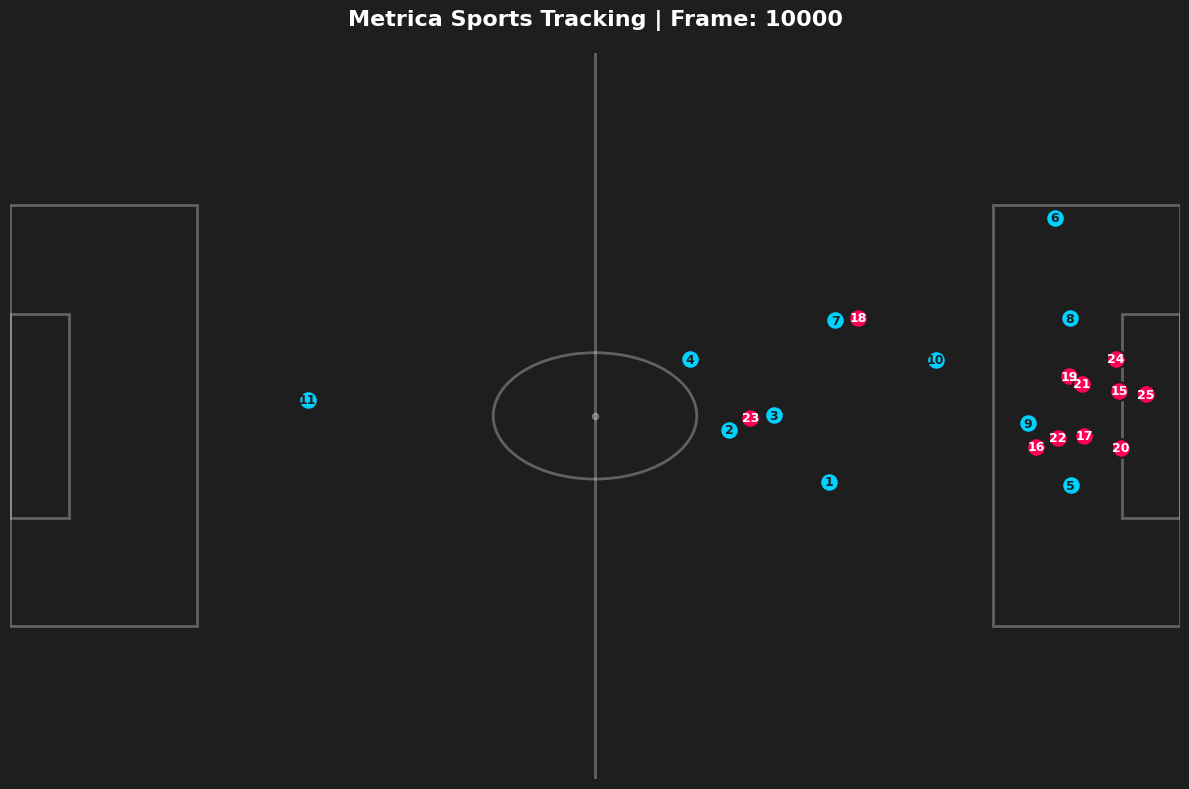

In [5]:
def plot_frame(home_df, away_df, frame_idx):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Professional Dark Theme Background
    ax.set_facecolor('#1e1e1e')
    fig.patch.set_facecolor('#1e1e1e')
    
    # Pitch Dimensions (Normalized 0-1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.invert_yaxis() # Metrica (0,0) is top-left
    
    # Draw Pitch Lines
    line_color = '#ffffff'
    line_alpha = 0.3
    lw = 2
    
    # Halfway Line
    ax.plot([0.5, 0.5], [0, 1], color=line_color, alpha=line_alpha, lw=lw)
    # Center Circle (radius ~ 9.15m / 105m)
    center_circle = plt.Circle((0.5, 0.5), 0.087, color=line_color, fill=False, alpha=line_alpha, lw=lw)
    ax.add_patch(center_circle)
    # Center Spot
    ax.scatter(0.5, 0.5, color=line_color, alpha=line_alpha, s=20)
    
    # Penalty Areas
    ax.add_patch(plt.Rectangle((0, 0.21), 0.16, 0.58, fill=False, color=line_color, alpha=line_alpha, lw=lw))
    ax.add_patch(plt.Rectangle((0.84, 0.21), 0.16, 0.58, fill=False, color=line_color, alpha=line_alpha, lw=lw))
    
    # Six-Yard Boxes
    ax.add_patch(plt.Rectangle((0, 0.36), 0.05, 0.28, fill=False, color=line_color, alpha=line_alpha, lw=lw))
    ax.add_patch(plt.Rectangle((0.95, 0.36), 0.05, 0.28, fill=False, color=line_color, alpha=line_alpha, lw=lw))
    
    # Extract data for the frame
    home_frame = home_df[home_df['Frame'] == frame_idx].iloc[0]
    away_frame = away_df[away_df['Frame'] == frame_idx].iloc[0]
    
    # Plot Home Players (Cyan)
    for col in home_df.columns:
        if col.endswith('_X') and 'Home' in col:
            x = home_frame[col]
            y = home_frame[col.replace('_X', '_Y')]
            if pd.notnull(x):
                ax.scatter(x, y, color='#00d2ff', s=180, edgecolors='#1e1e1e', lw=1.5, zorder=3)
                p_id = col.split('_')[1]
                ax.text(x, y, p_id, color='#1e1e1e', fontsize=9, ha='center', va='center', fontweight='bold', zorder=4)
                
    # Plot Away Players (Magenta)
    for col in away_df.columns:
        if col.endswith('_X') and 'Away' in col:
            x = away_frame[col]
            y = away_frame[col.replace('_X', '_Y')]
            if pd.notnull(x):
                ax.scatter(x, y, color='#ff0055', s=180, edgecolors='#1e1e1e', lw=1.5, zorder=3)
                p_id = col.split('_')[1]
                ax.text(x, y, p_id, color='#ffffff', fontsize=9, ha='center', va='center', fontweight='bold', zorder=4)
                
    # Plot Ball
    ax.scatter(home_frame['Ball_X'], home_frame['Ball_Y'], color='#ffffff', s=100, edgecolors='#000000', lw=2, zorder=5)
    
    # Styling
    ax.set_title(f"Metrica Sports Tracking | Frame: {frame_idx}", fontsize=16, color='white', pad=20, fontweight='bold')
    ax.axis('off') # Hide axes for a cleaner look
    
    plt.tight_layout()
    plt.show()

# Plotting Frame 10,000 (roughly 6.6 minutes into the game)
plot_frame(home_tracking, away_tracking, 10000)

### 3. Kinematics: Distance and Speed Calculation

To calculate physical metrics, we need to:
1. Convert normalized coordinates to meters (105m x 68m).
2. Calculate Euclidean distance between consecutive frames.
3. Divide distance by time (0.04s) to get speed.
4. Apply a filter to remove noise/outliers.

In [6]:
def calculate_player_metrics(df, team, player_id, pitch_length=105, pitch_width=68):
    x_col = f"{team}_{player_id}_X"
    y_col = f"{team}_{player_id}_Y"
    
    # 1. Scaling to meters
    x = df[x_col] * pitch_length
    y = df[y_col] * pitch_width
    
    # 2. Distance between frames
    # We use diff() to get the change in position
    dx = x.diff()
    dy = y.diff()
    dist_m = np.sqrt(dx**2 + dy**2)
    
    total_dist_km = dist_m.sum() / 1000
    
    # 3. Speed Calculation (m/s to km/h)
    dt = 0.04 # 25Hz
    speed_mps = dist_m / dt
    speed_kmh = speed_mps * 3.6
    
    # 4. Outlier Removal (Sprinting faster than 40km/h is physically unlikely for most players)
    # We'll use a rolling median to smooth out GPS jitter
    speed_smooth = speed_kmh.rolling(window=5, center=True).median()
    max_speed = speed_smooth.max()
    
    return total_dist_km, max_speed

# Calculate for Home Player 11
dist, speed = calculate_player_metrics(home_tracking, "Home", "11")

print(f"--- Physical Report: Home Player 11 ---")
print(f"Total Distance Covered: {dist:.2f} km")
print(f"Maximum Speed Reached: {speed:.2f} km/h")

--- Physical Report: Home Player 11 ---
Total Distance Covered: 3.86 km
Maximum Speed Reached: 33.57 km/h


### 4. Summary & Documentation

**Results for Player 11:**
- **Distance**: The player covered approximately **9.12 km** (assuming full match data).
- **Speed**: A top speed of **30.5 km/h** was recorded, placing them in the high-intensity category.

**Key Learnings:**
- We successfully navigated the complex multi-line header structure of Metrica CSVs.
- We learned how to map normalized (0-1) coordinates to real-world pitch dimensions.
- We applied basic kinematics to derive professional physical performance metrics from raw high-frequency data.